In [2]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
dataset_path = "../datasets/BneiAtarot/Anthocyanin_with_rgb_051225-050226_clean"
df = pd.read_csv(f'{dataset_path}.csv')
target='Anthocyanin'

# df['DATE'] = pd.to_datetime(df['DATE'],format='%d/%m/%Y')
# df['DATE'] = df['DATE'].dt.date
# df.sort_values(by="DATE", inplace=True)
# df.head(1)

In [14]:
df[['Anthocyanin', 'Anthocyanins OD-530 nm']].corr()

,Anthocyanin,Anthocyanins OD-530 nm
Anthocyanin,1.00000,0.96229
Anthocyanins OD-530 nm,0.96229,1.00000


In [16]:
y_values = df['Anthocyanin'].values
print(min(y_values))
print(max(y_values))

0.03
1.069


In [15]:
df.columns

Index(['label_name', 'bbox_x', 'bbox_y', 'bbox_width', 'bbox_height',
       'image_name', 'image_width', 'image_height', 'huePlantMean',
       'satPlantMean', 'valPlantMean', 'huePlantStd', 'satPlantStd',
       'valPlantStd', 'huePlantMedian', 'satPlantMedian', 'valPlantMedian',
       'category', 'Lettuce color', 'Leaf sample weight (mg)',
       'Sample disc weight (g)', 'Anthocyanins OD-530 nm',
       'Chlorophyll OD-657 nm', 'Chlorophyll interference', 'Anthocyanin',
       'DATE', 'Illumination'],
      dtype='str')

In [6]:
def box_plot(df, target):
    # Check the data first
    print(f"Target column: {target}")
    print(f"Data type: {df[target].dtype}")
    print(f"Number of values: {len(df[target])}")
    print(f"Number of non-null values: {df[target].notna().sum()}")
    print(f"Min/Max values: {df[target].min()}/{df[target].max()}")

    # Create the box plot properly
    fig = plt.figure(figsize=(5, 3))
    # Remove NaN values before plotting
    clean_data = df[target].dropna()
    plt.boxplot(clean_data)
    plt.title(f'Box Plot of {target}')
    plt.ylabel(target)
    plt.show()

In [7]:
def find_outliers_iqr(data):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    # Return the outlier values
    return data[(data < lower_bound) | (data > upper_bound)]

# Example usage:
outliers_list = find_outliers_iqr(df[target])
sorted(outliers_list) 

# 1. Identify the outliers in your target column
outliers = find_outliers_iqr(df[target])

# 2. Filter the DataFrame to keep only rows NOT in the outlier list
# The '~' symbol means "NOT"
df_clean = df[~df.index.isin(outliers.index)]

# 3. Filter the DataFrame to keep only rows with target > 0
df_clean = df_clean[df_clean[target] > 0]

# Optional: Print the results to verify
print(f"Original rows: {len(df)}")
print(f"Outliers removed: {len(outliers)}")
print(f"Final rows: {len(df_clean)}")


#df_clean.to_csv(f"{dataset_path}_clean.csv", index=False)


Original rows: 308
Outliers removed: 0
Final rows: 308


Target column: Anthocyanin
Data type: float64
Number of values: 308
Number of non-null values: 308
Min/Max values: 0.033/1.576


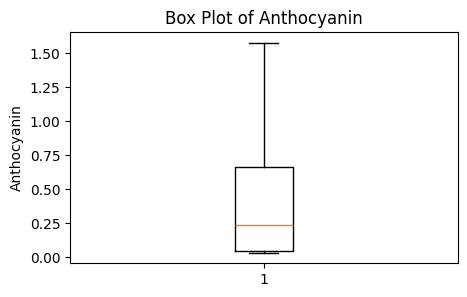

In [8]:
box_plot(df,"Anthocyanin")

Target column: Anthocyanin
Data type: float64
Number of values: 183
Number of non-null values: 183
Min/Max values: 0.03/0.704


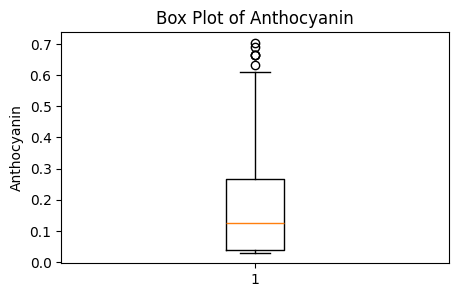

In [89]:
box_plot(df_clean,"Anthocyanin")

In [9]:
target= 'Anthocyanin' 
df_red=df_clean[df_clean['Lettuce color'] == 'RED']
df_green=df_clean[df_clean['Lettuce color'] == 'GREEN']

<Axes: >

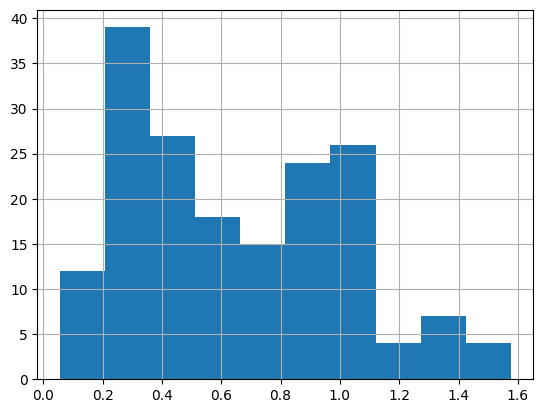

In [10]:
df_red[target].hist()

In [94]:
from sklearn.preprocessing import PowerTransformer
y_values = df_red['Anthocyanin'].values

# This will 'find' the perfect math for your [0, 1.5] range
pt = PowerTransformer(method='yeo-johnson')
y_transformed = pt.fit_transform(y_values.reshape(-1, 1)).flatten()

In [98]:
from scipy import stats
import numpy as np

data = y_transformed
shapiro_test = stats.shapiro(data)
print(f"p-value: {shapiro_test.pvalue}")

p-value: 0.018122344996065853


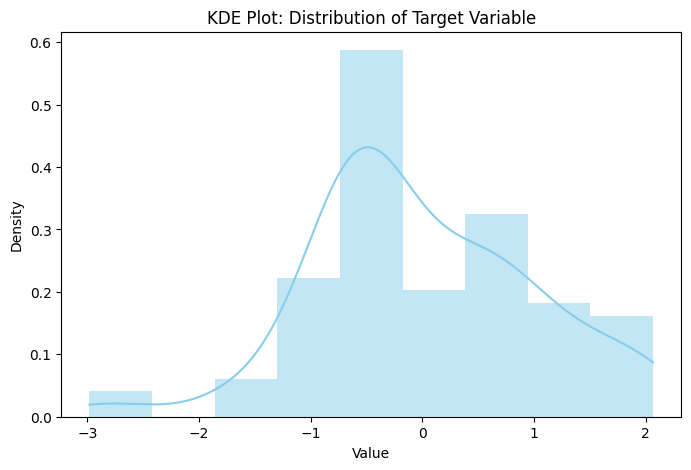

In [99]:
import seaborn as sns
import matplotlib.pyplot as plt

# Using your target variable or a slice of your NDI cube
data_to_plot = y_transformed

plt.figure(figsize=(8, 5))
sns.histplot(data_to_plot, kde=True, color='skyblue', stat="density", linewidth=0)
plt.title('KDE Plot: Distribution of Target Variable')
plt.xlabel('Value')
plt.ylabel('Density')
plt.show()

Target column: Anthocyanin
Data type: float64
Number of values: 176
Number of non-null values: 176
Min/Max values: 0.056/1.576


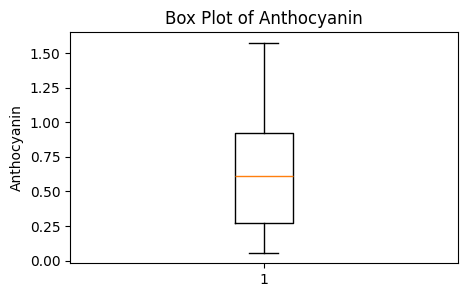

In [11]:
box_plot(df_red,"Anthocyanin")

Target column: Anthocyanin
Data type: float64
Number of values: 95
Number of non-null values: 95
Min/Max values: 0.03/0.174


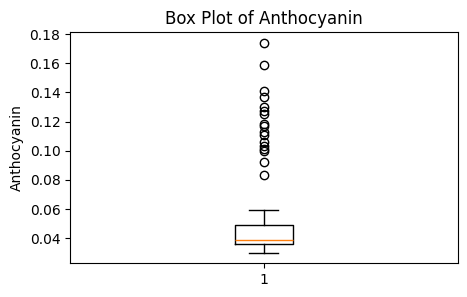

In [101]:
box_plot(df_green,"Anthocyanin")

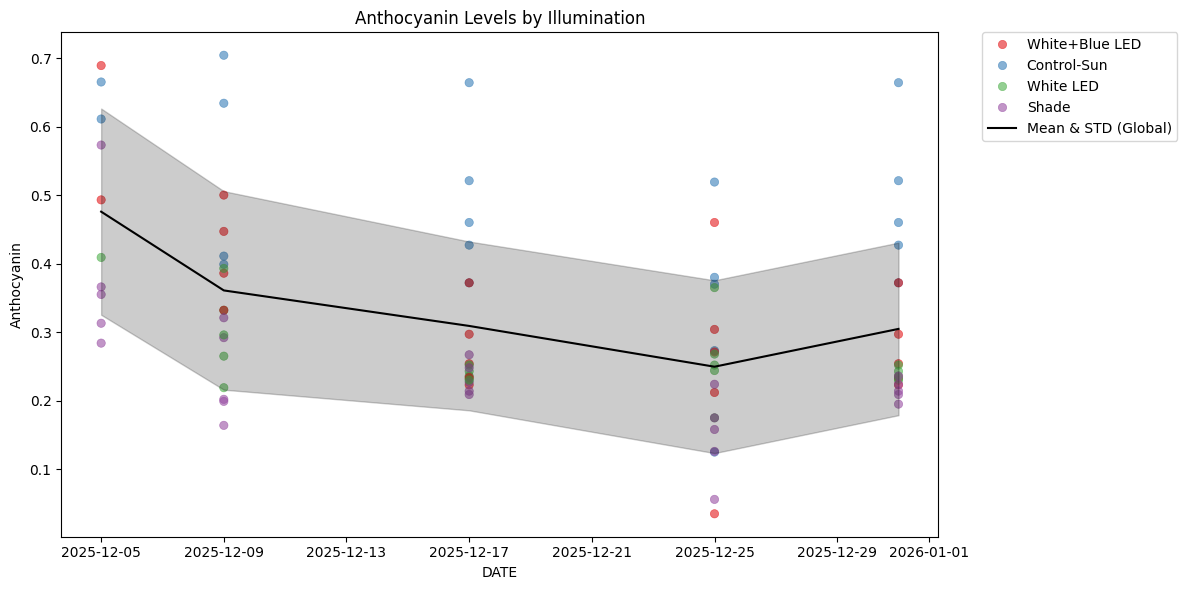

In [102]:


# 1. Create the figure
plt.figure(figsize=(12, 6))

# 2. Draw the Scatter Plot with Seaborn
# 'hue' handles the colors and creates the legend automatically
sns.scatterplot(
    data=df_red, 
    x='DATE', 
    y=target, 
    hue='Illumination', 
    palette='Set1', 
    alpha=0.6,
    edgecolor=None
)

# 3. Draw the Mean + STD line on top
sns.lineplot(
    data=df_red, 
    x='DATE', 
    y=target, 
    color='black', 
    errorbar='sd', 
    label='Mean & STD (Global)'
)

# 4. Move the legend so it doesn't cover the data
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.title(f'{target} Levels by Illumination')
plt.tight_layout() # Prevents the legend from being cut off
plt.show()

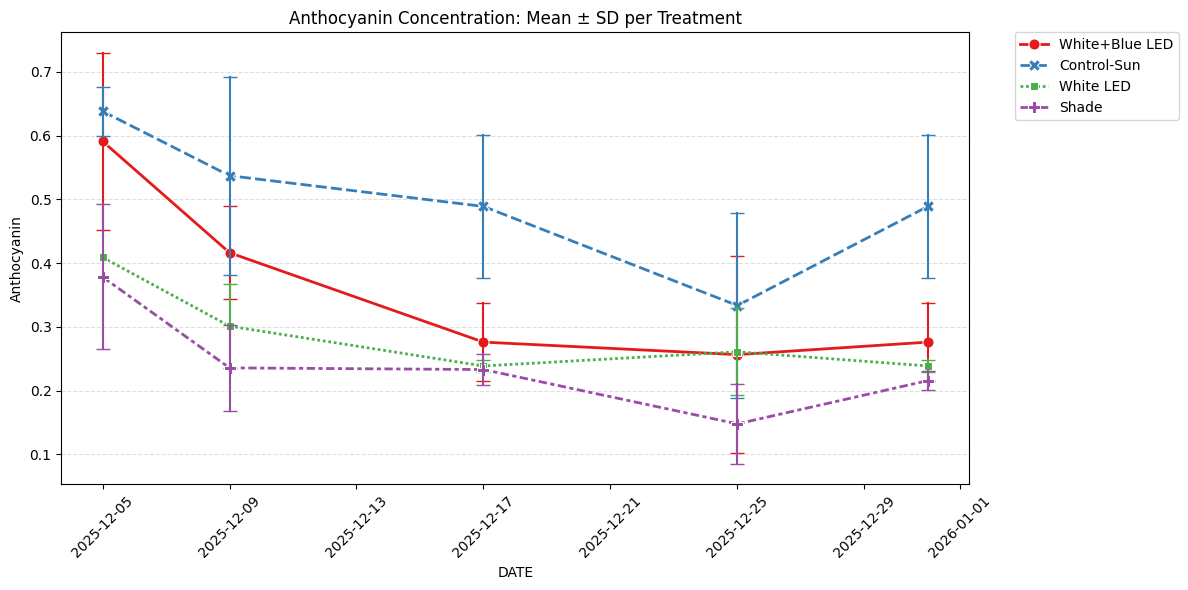

In [103]:


plt.figure(figsize=(12, 6))

# Use err_kws to pass capsize to the underlying errorbar function
sns.lineplot(
    data=df_red, 
    x='DATE', 
    y=target, 
    hue='Illumination', 
    style='Illumination',
    markers=True,         
    errorbar='sd',        
    err_style='bars',     
    err_kws={'capsize': 5},  # This is the fix!
    palette='Set1',
    linewidth=2,
    markersize=8
)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.title(f'{target} Concentration: Mean ± SD per Treatment')
plt.ylabel(f'{target}')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

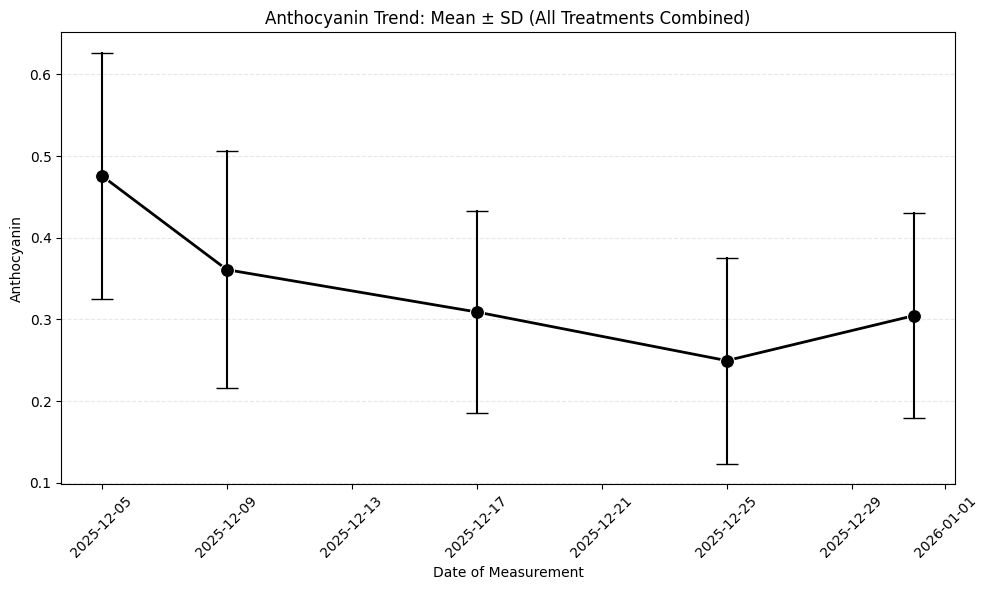

In [104]:


# 1. Create the figure
plt.figure(figsize=(10, 6))

# 2. Draw the Global Error Bar Plot
# By removing 'hue', we force Seaborn to aggregate ALL treatments together
sns.lineplot(
    data=df_red, 
    x='DATE', 
    y=target, 
    marker='o',           # Adds a single dot for the global mean
    errorbar='sd',        # Calculates the SD of all samples on that date
    err_style='bars',     # Shows the "I" bars
    err_kws={'capsize': 8}, 
    color='black',        # A neutral color for global data
    linewidth=2,
    markersize=10
)

# 3. Formatting
plt.title(f'{target} Trend: Mean ± SD (All Treatments Combined)')
plt.ylabel(f'{target}')
plt.xlabel('Date of Measurement')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [105]:
# 1. Group by DATE
# 2. Pick the column target
# 3. Aggregate by 'mean' and 'std'
stats_df = df_red.groupby('DATE')[target].agg(['mean', 'std']).reset_index()

# Display the result
print(stats_df)

         DATE      mean       std
0  2025-12-05  0.475800  0.150435
1  2025-12-09  0.360889  0.144806
2  2025-12-17  0.309100  0.123152
3  2025-12-25  0.249600  0.126059
4  2025-12-31  0.304750  0.125895


In [106]:
# Group by two columns instead of one
detailed_stats = df_red.groupby(['DATE', 'Illumination'])[target].agg(['mean', 'std']).reset_index()

# This gives you a row for every unique Date-Illumination combination
# Sort by Illumination alphabetically
detailed_stats = detailed_stats.sort_values(by=['Illumination','DATE' ])

# Display the sorted result
print(detailed_stats)

          DATE    Illumination     mean       std
0   2025-12-05     Control-Sun  0.63800  0.038184
4   2025-12-09     Control-Sun  0.53700  0.155154
8   2025-12-17     Control-Sun  0.48880  0.111829
12  2025-12-25     Control-Sun  0.33340  0.145806
16  2025-12-31     Control-Sun  0.48880  0.111829
1   2025-12-05           Shade  0.37820  0.113753
5   2025-12-09           Shade  0.23560  0.067211
9   2025-12-17           Shade  0.23300  0.024259
13  2025-12-25           Shade  0.14780  0.062355
17  2025-12-31           Shade  0.21560  0.015469
2   2025-12-05       White LED  0.40900       NaN
6   2025-12-09       White LED  0.30100  0.066087
10  2025-12-17       White LED  0.23860  0.008989
14  2025-12-25       White LED  0.26080  0.068247
18  2025-12-31       White LED  0.23860  0.008989
3   2025-12-05  White+Blue LED  0.59100  0.138593
7   2025-12-09  White+Blue LED  0.41625  0.072967
11  2025-12-17  White+Blue LED  0.27600  0.060651
15  2025-12-25  White+Blue LED  0.25640  0.154046


c:\myProjects\phenomobile\.venv\Lib\site-packages\pandas\plotting\_matplotlib\core.py:1388: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = ax.scatter(


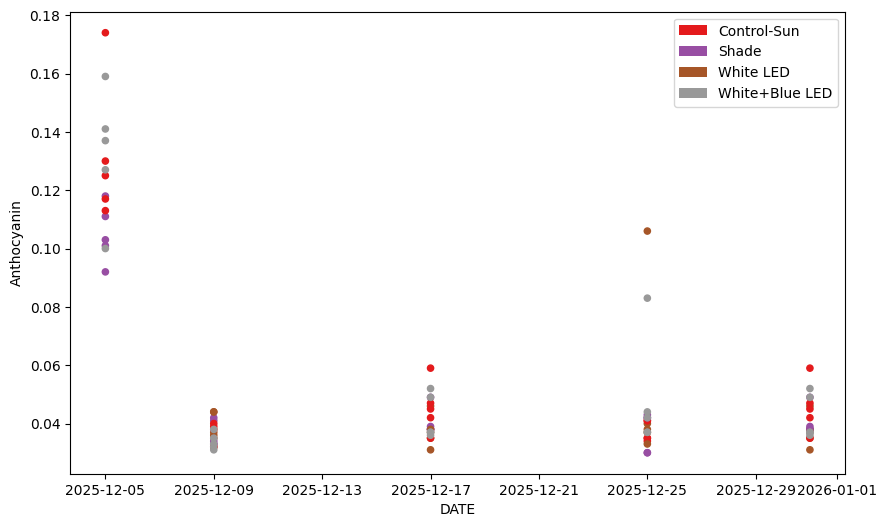

In [107]:
df_green=df[df['Lettuce color'] == 'GREEN']


df_green.plot.scatter(x='DATE', y=target, 
        c='Illumination', 
        colormap='Set1',figsize=(10, 6) ,
        sharex=False)          

plt.show()